## Step 1: Imports and setup

In [1]:
import os
import re
import json
from datetime import datetime
from typing import Literal

import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

load_dotenv()

from langchain_deepseek import ChatDeepSeek

load_dotenv()

API_KEY = os.getenv("DEEPSEEK_API_KEY", "")
MODEL_NAME = os.getenv("DEEPSEEK_MODEL", "deepseek-flash")

# if key is missing or still the placeholder we skip the LLM and use rule engine only
USE_LLM = bool(API_KEY) and not API_KEY.startswith("your_")
print("model:", MODEL_NAME)
print("LLM on:", USE_LLM)

model: deepseek-flash
LLM on: True


## Step 2: Claims data and policy

In [2]:
# the 5 sample claims from appendix B
claims = [
    {
        "claim_id": "CLM-001", "employee": "A. Rivera",
        "purpose": "Attend 2-day industry conference (business)",
        "trip_start": "2026-06-10", "trip_end": "2026-06-12", "submitted": "2026-06-20",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $180", "nights": 2, "amount": 360.00, "receipt": True},
            {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt": True},
            {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt": True},
        ],
    },
    {
        "claim_id": "CLM-002", "employee": "B. Osei",
        "purpose": "Weekend hotel stay",
        "trip_start": "2026-06-14", "trip_end": "2026-06-15", "submitted": "2026-06-25",
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt": True},
        ],
    },
    {
        "claim_id": "CLM-003", "employee": "C. Nakamura",
        "purpose": "Client site visit (business)",
        "trip_start": "2026-06-08", "trip_end": "2026-06-10", "submitted": "2026-06-22",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "nights": 2, "amount": 500.00, "receipt": True},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt": True},
        ],
    },
    {
        "claim_id": "CLM-004", "employee": "D. Fischer",
        "purpose": "International vendor negotiation (business)",
        "trip_start": "2026-06-16", "trip_end": "2026-06-18", "submitted": "2026-06-28",
        "items": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt": True},
            {"category": "lodging", "description": "Hotel, 3 nights", "nights": 3, "amount": 600.00, "receipt": False},
        ],
    },
    {
        "claim_id": "CLM-005", "employee": "E. Haddad",
        "purpose": "Client dinner / business development",
        "trip_start": "2026-06-11", "trip_end": "2026-06-11", "submitted": "2026-06-24",
        "items": [
            {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt": False},
        ],
    },
]

# policy from appendix A
policy = {
    "POL-CAT-01": "Eligible categories (need a business purpose): airfare (economy only), lodging, meals (per diem limit), ground transport (taxi, rideshare, train, rental car, parking), conference or registration fees.",
    "POL-CAT-02": "Ineligible items, never reimbursable, deducted in full: alcohol and minibar, spa, gym, personal entertainment, in-room movies, personal shopping, gifts, traffic fines, penalties, late fees, any personal expense.",
    "POL-PD-01": "Meals max $75 per day. Amount above the daily cap is deducted, rest is reimbursed.",
    "POL-PD-02": "Lodging max $200 per night. Amount above the nightly cap is deducted, rest is reimbursed.",
    "POL-PD-03": "Ground transport max $50 per day. Amount above the cap is deducted.",
    "POL-AIR-01": "Only economy airfare is reimbursable. Business or first class is a policy exception and must go to Manual Review (not auto deducted, a pre-approval may exist).",
    "POL-RCT-01": "Any single line item over $25 needs an itemized receipt. Airfare and lodging always need a receipt whatever the amount.",
    "POL-RCT-02": "Missing receipt is not silently rejected. Claim goes to Manual Review so reviewer can ask for the receipt.",
    "POL-APR-01": "Total reimbursable up to $500 can be auto approved by the agent if fully compliant.",
    "POL-APR-02": "Total over $500 and up to $2,000 is manager tier, approvable when fully compliant.",
    "POL-APR-03": "Total over $2,000 is director tier, above agent authority, must go to Manual Review even if compliant.",
    "POL-TIME-01": "Claims must be submitted within 30 days of the expense date. Late claims go to Manual Review.",
}

# limits
LIMITS = {
    "meals_per_day": 75,
    "lodging_per_night": 200,
    "ground_per_day": 50,
    "receipt_over": 25,
    "auto_tier": 500,
    "manager_tier": 2000,
    "submit_days": 30,
}

# category groups
ELIGIBLE = {"airfare", "lodging", "meals", "conference_fees",
            "ground_transport", "taxi", "rideshare", "train", "rental_car", "parking"}
GROUND = {"ground_transport", "taxi", "rideshare", "train", "rental_car", "parking"}
INELIGIBLE = {"alcohol", "minibar", "spa", "gym", "entertainment", "movies",
              "shopping", "gifts", "fines", "penalty", "late_fee", "personal"}


## Step 3: checks

All the policy math is here.

In [3]:
def get_claim(claim_id):
    """find claim by id"""
    for c in claims:
        if c["claim_id"] == claim_id:
            return c
    raise ValueError("claim not found: " + claim_id)


def to_date(s):
    return datetime.strptime(s, "%Y-%m-%d").date()


def trip_days(claim):
    """days are inclusive so 10th to 12th is 3 days and 2 nights"""
    days = (to_date(claim["trip_end"]) - to_date(claim["trip_start"])).days + 1
    nights = max(days - 1, 1) 
    return days, nights


def is_group_meal(item):
    """checks text like 'dinner for 4', per diem is for one person so this is unclear"""
    m = re.search(r"for (\d+)", item["description"].lower())
    return bool(m) and int(m.group(1)) > 1


def check_eligibility_plain(claim):
    """split items into eligible / ineligible / unknown category"""
    eligible, ineligible, unknown = [], [], []
    for it in claim["items"]:
        if it["category"] in ELIGIBLE:
            eligible.append(it)
        elif it["category"] in INELIGIBLE:
            ineligible.append(it)
        else:
            unknown.append(it)

    refs = []
    if eligible:
        refs.append("POL-CAT-01")
    if ineligible:
        refs.append("POL-CAT-02")

    return {
        "eligible_items": eligible,
        "ineligible_items": ineligible,
        "unknown_items": unknown,
        "ineligible_total": round(sum(i["amount"] for i in ineligible), 2),
        "policy_refs": refs,
    }


def check_limits_plain(claim):
    """per diem and category caps for meals, lodging, ground transport"""
    days, nights = trip_days(claim)
    deductions = {}
    details = []
    ambiguous = []
    refs = []

    # meals, per day
    meals = [i for i in claim["items"] if i["category"] == "meals"]
    if meals:
        refs.append("POL-PD-01")
        normal = [i for i in meals if not is_group_meal(i)]
        for g in [i for i in meals if is_group_meal(i)]:
            ambiguous.append("group meal '" + g["description"] + "' ($%.2f), per diem is per day so cap is unclear (POL-PD-01)" % g["amount"])
        total = sum(i["amount"] for i in normal)
        cap = LIMITS["meals_per_day"] * days
        over = max(0, total - cap)
        if normal:
            deductions["meals"] = round(over, 2)
            details.append("meals $%.2f vs cap $%.2f (%d days x $%d)" % (total, cap, days, LIMITS["meals_per_day"]))

    # lodging, per night
    lodging = [i for i in claim["items"] if i["category"] == "lodging"]
    if lodging:
        refs.append("POL-PD-02")
        total = sum(i["amount"] for i in lodging)
        # use the nights written on the claim, if not there use the trip dates
        stated = sum(i.get("nights", 0) for i in lodging)
        used_nights = stated if stated else nights
        if stated and stated != days - 1:
            ambiguous.append("lodging says %d nights but trip dates give %d, conflicting info" % (stated, days - 1))
        cap = LIMITS["lodging_per_night"] * used_nights
        deductions["lodging"] = round(max(0, total - cap), 2)
        details.append("lodging $%.2f vs cap $%.2f (%d nights x $%d)" % (total, cap, used_nights, LIMITS["lodging_per_night"]))

    # ground transport, per day
    ground = [i for i in claim["items"] if i["category"] in GROUND]
    if ground:
        refs.append("POL-PD-03")
        total = sum(i["amount"] for i in ground)
        cap = LIMITS["ground_per_day"] * days
        deductions["ground_transport"] = round(max(0, total - cap), 2)
        details.append("ground transport $%.2f vs cap $%.2f (%d days x $%d)" % (total, cap, days, LIMITS["ground_per_day"]))

    return {
        "days": days,
        "nights": nights,
        "deductions": deductions,
        "total_deducted": round(sum(deductions.values()), 2),
        "details": details,
        "ambiguous": ambiguous,
        "policy_refs": refs,
    }


def check_receipts_plain(claim):
    """receipt needed for airfare, lodging or any item over $25 (only for eligible items)"""
    missing = []
    needed_any = False
    for it in claim["items"]:
        if it["category"] not in ELIGIBLE:
            continue
        needs = it["category"] in ("airfare", "lodging") or it["amount"] > LIMITS["receipt_over"]
        if needs:
            needed_any = True
            if not it["receipt"]:
                missing.append("Receipt for %s (%s) $%.2f" % (it["category"], it["description"], it["amount"]))

    refs = []
    if needed_any:
        refs.append("POL-RCT-01")
    if missing:
        refs.append("POL-RCT-02")
    return {"missing": missing, "policy_refs": refs}


def check_approval_plain(claim):
    """total tier, 30 day window and airfare class"""
    elig = check_eligibility_plain(claim)
    lim = check_limits_plain(claim)

    eligible_total = sum(i["amount"] for i in elig["eligible_items"])
    total = round(eligible_total - lim["total_deducted"], 2)

    # tier
    refs = []
    if total <= LIMITS["auto_tier"]:
        tier, tier_ref = "auto-approve", "POL-APR-01"
    elif total <= LIMITS["manager_tier"]:
        tier, tier_ref = "manager", "POL-APR-02"
    else:
        tier, tier_ref = "director", "POL-APR-03"
    if elig["eligible_items"]:
        refs.append(tier_ref)

    # timeliness (using trip end date as expense date)
    days_since = (to_date(claim["submitted"]) - to_date(claim["trip_end"])).days
    late = days_since > LIMITS["submit_days"]
    if late:
        refs.append("POL-TIME-01")

    # airfare class
    business_class, unknown_class = [], []
    for it in claim["items"]:
        if it["category"] == "airfare":
            d = it["description"].lower()
            if "business" in d or "first" in d:
                business_class.append(it["description"])
            elif "economy" not in d:
                unknown_class.append(it["description"])
    if business_class or unknown_class:
        refs.append("POL-AIR-01")

    return {
        "total_reimbursable": total,
        "tier": tier,
        "needs_director": tier == "director",
        "days_since_expense": days_since,
        "late": late,
        "business_class_items": business_class,
        "unknown_class_items": unknown_class,
        "policy_refs": refs,
    }

## Step 4: LangChain tools

`@tool` wrappers on the checks above. They only take `claim_id` so the small model cant break big json args. The docstring is what the LLM reads to pick the tool.

In [4]:
@tool
def lookup_policy(topic: str) -> dict:
    """Search the travel policy by keyword (example: meals, lodging, receipt, airfare, late) or by rule id (example: POL-PD-01). Returns matching rules with their ids."""
    words = topic.lower().split()
    found = {}
    for rule_id, text in policy.items():
        hay = (rule_id + " " + text).lower()
        if any(w in hay for w in words):
            found[rule_id] = text
    # only send top 5 so the model is not flooded
    return {"matches": dict(list(found.items())[:5])}


@tool
def check_eligibility(claim_id: str) -> dict:
    """Check which items in the claim are eligible, ineligible (spa, minibar, alcohol etc) or unknown category. Input is the claim id like CLM-001."""
    r = check_eligibility_plain(get_claim(claim_id))
    return {
        "eligible": [(i["category"], i["amount"]) for i in r["eligible_items"]],
        "ineligible": [(i["category"], i["amount"]) for i in r["ineligible_items"]],
        "unknown_category": [(i["category"], i["amount"]) for i in r["unknown_items"]],
        "ineligible_total": r["ineligible_total"],
        "policy_refs": r["policy_refs"],
    }


@tool
def check_limits(claim_id: str) -> dict:
    """Check per diem and category limits (meals per day, lodging per night, ground transport per day) and return the deducted amount. Input is the claim id like CLM-001."""
    return check_limits_plain(get_claim(claim_id))


@tool
def check_receipts(claim_id: str) -> dict:
    """Check receipt completeness. Airfare, lodging and any item over $25 need a receipt. Returns the list of missing receipts. Input is the claim id like CLM-001."""
    return check_receipts_plain(get_claim(claim_id))


@tool
def check_approval_rules(claim_id: str) -> dict:
    """Check the approval tier of the total reimbursable amount, the 30 day submission window and the airfare class (business or first class). Input is the claim id like CLM-001."""
    return check_approval_plain(get_claim(claim_id))


tools = [lookup_policy, check_eligibility, check_limits, check_receipts, check_approval_rules]
tool_names = {t.name for t in tools}

# quick test of a tool by hand, no LLM yet
print(check_limits.invoke({"claim_id": "CLM-003"}))
print(lookup_policy.invoke({"topic": "receipt"}))

{'days': 3, 'nights': 2, 'deductions': {'meals': 0, 'lodging': 100.0}, 'total_deducted': 100.0, 'details': ['meals $140.00 vs cap $225.00 (3 days x $75)', 'lodging $500.00 vs cap $400.00 (2 nights x $200)'], 'ambiguous': [], 'policy_refs': ['POL-PD-01', 'POL-PD-02']}
{'matches': {'POL-RCT-01': 'Any single line item over $25 needs an itemized receipt. Airfare and lodging always need a receipt whatever the amount.', 'POL-RCT-02': 'Missing receipt is not silently rejected. Claim goes to Manual Review so reviewer can ask for the receipt.'}}


## Step 5: Rule engine (safety net)

Applies the "Decision Guidance" from the policy using the plain checks. This is also my answer key to check the agent against.

In [5]:
def rule_engine(claim_id):
    """decide a claim only with plain rules, no LLM"""
    claim = get_claim(claim_id)
    elig = check_eligibility_plain(claim)
    lim = check_limits_plain(claim)
    rec = check_receipts_plain(claim)
    appr = check_approval_plain(claim)

    claimed_total = round(sum(i["amount"] for i in claim["items"]), 2)
    definite_deduct = round(elig["ineligible_total"] + lim["total_deducted"], 2)
    refs = sorted(set(elig["policy_refs"] + lim["policy_refs"] + rec["policy_refs"] + appr["policy_refs"]))

    # collect every reason that needs a human
    reasons = []
    ambiguity = False
    if elig["unknown_items"]:
        reasons.append("unknown expense category, cannot tell if eligible (POL-CAT-01)")
        ambiguity = True
    for a in lim["ambiguous"]:
        reasons.append(a)
        ambiguity = True
    if rec["missing"]:
        reasons.append("missing required receipt, reviewer should ask for it (POL-RCT-02)")
    if appr["business_class_items"]:
        reasons.append("business or first class airfare is a policy exception, maybe pre-approved (POL-AIR-01)")
    if appr["unknown_class_items"]:
        reasons.append("airfare class is not clear (POL-AIR-01)")
        ambiguity = True
    if appr["needs_director"]:
        reasons.append("total $%.2f is over $2,000, needs director approval (POL-APR-03)" % appr["total_reimbursable"])
    if appr["late"]:
        reasons.append("submitted %d days after the expense, over the 30 day window (POL-TIME-01)" % appr["days_since_expense"])

    # decision
    if not elig["eligible_items"] and not elig["unknown_items"]:
        decision = "REJECT"
        approved, deducted = 0.0, claimed_total
        names = ", ".join(i["category"] for i in elig["ineligible_items"])
        explanation = "All items are ineligible (%s) so nothing can be reimbursed. Full $%.2f deducted (POL-CAT-02)." % (names, deducted)
        confidence = 0.95
    elif reasons:
        decision = "MANUAL_REVIEW"
        approved, deducted = 0.0, definite_deduct
        explanation = "Sent to manual review: " + "; ".join(reasons) + "."
        confidence = 0.6 if ambiguity else 0.85
    elif definite_deduct > 0:
        decision = "PARTIAL_APPROVE"
        approved, deducted = round(claimed_total - definite_deduct, 2), definite_deduct
        parts = []
        if elig["ineligible_total"] > 0:
            parts.append("ineligible items $%.2f (POL-CAT-02)" % elig["ineligible_total"])
        for cat, amt in lim["deductions"].items():
            if amt > 0:
                parts.append("%s over the cap by $%.2f" % (cat, amt))
        explanation = "Claim is valid but some amount is deducted: " + ", ".join(parts) + ". Approved $%.2f." % approved
        confidence = 0.9
    else:
        decision = "APPROVE"
        approved, deducted = claimed_total, 0.0
        explanation = "All items eligible, receipts are there and within per diem limits. Total $%.2f is in the %s tier." % (approved, appr["tier"])
        confidence = 0.95

    return {
        "claim_id": claim_id,
        "decision": decision,
        "approved_amount": round(approved, 2),
        "deducted_amount": round(deducted, 2),
        "missing_docs": rec["missing"],
        "policy_refs": refs,
        "confidence": confidence,
        "explanation": explanation,
        "tools_used": ["check_eligibility", "check_limits", "check_receipts", "check_approval_rules"],
    }


# check against what I worked out by hand
expected = {
    "CLM-001": ("APPROVE", 1110.0, 0.0),
    "CLM-002": ("REJECT", 0.0, 380.0),
    "CLM-003": ("PARTIAL_APPROVE", 840.0, 100.0),
    "CLM-004": ("MANUAL_REVIEW", 0.0, 0.0),
    "CLM-005": ("MANUAL_REVIEW", 0.0, 0.0),
}
for cid, exp in expected.items():
    r = rule_engine(cid)
    got = (r["decision"], r["approved_amount"], r["deducted_amount"])
    print(cid, "OK" if got == exp else "MISMATCH", got)

CLM-001 OK ('APPROVE', 1110.0, 0.0)
CLM-002 OK ('REJECT', 0.0, 380.0)
CLM-003 OK ('PARTIAL_APPROVE', 840.0, 100.0)
CLM-004 OK ('MANUAL_REVIEW', 0.0, 0)
CLM-005 OK ('MANUAL_REVIEW', 0.0, 0)


## Step 6: Output schemas (Pydantic)

`AgentVerdict` is what the LLM must return (small on purpose). `ClaimResult` is the final 9 fields we validate.

In [6]:
Decision = Literal["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]


class AgentVerdict(BaseModel):
    """Final verdict for the claim after all tool checks are done."""
    decision: Decision = Field(description="APPROVE, PARTIAL_APPROVE, REJECT or MANUAL_REVIEW")
    explanation: str = Field(description="2 or 3 short sentences, cite policy ids like POL-PD-02")


class ClaimResult(BaseModel):
    """"""
    claim_id: str
    decision: Decision
    approved_amount: float = Field(ge=0)
    deducted_amount: float = Field(ge=0)
    missing_docs: list[str]
    policy_refs: list[str]
    confidence: float = Field(ge=0, le=1)
    explanation: str
    tools_used: list[str]

## Step 7: agent

`create_agent` from LangChain v1 with a HuggingFace chat model, the tools and a structured response (`ToolStrategy`). The agent decides which tools to call.

In [7]:
SYSTEM_PROMPT = """You are a travel reimbursement reviewer.
You get a claim id. Use the tools to check the claim before deciding:
- check_eligibility, check_limits, check_receipts, check_approval_rules (all take claim_id)
- lookup_policy if you want to read a policy rule

Decision rules:
- REJECT only when nothing in the claim is reimbursable (all items ineligible).
- PARTIAL_APPROVE when the claim is valid but some amount is deducted (over the per diem cap or ineligible items).
- APPROVE when everything is eligible, has receipts and is within limits.
- MANUAL_REVIEW for missing receipts, business or first class airfare, total over 2000, late claim, or anything unclear or conflicting.
When you are not sure, choose MANUAL_REVIEW.
Do not do the math yourself, trust the tool results.
When done, give the final decision and a short explanation that cites policy ids."""

chat_model = None  # set inside build_agent


def build_agent():
    """make the deepseek chat model and wrap it in a langchain agent"""
    global chat_model
    chat_model = ChatDeepSeek(
        model=MODEL_NAME,
        temperature=0,
        max_retries=2,
        api_key=API_KEY,
    )
    return create_agent(
        model=chat_model,
        tools=tools,
        system_prompt=SYSTEM_PROMPT,
    )

agent = build_agent() if USE_LLM else None
print("agent ready:", agent is not None)


def run_agent(claim_id):
    """run the agent on one claim, returns verdict and the tools it really called"""
    out = agent.invoke(
        {"messages": [{"role": "user", "content": "Review travel claim " + claim_id + " and give the final decision."}]},
        config={"recursion_limit": 15},
    )

    # read the tool calls from the message history
    used = []
    for m in out["messages"]:
        if m.type == "ai":
            for tc in m.tool_calls:
                if tc["name"] in tool_names and tc["name"] not in used:
                    used.append(tc["name"])

    # last message is the agent final answer in plain text
    final_text = out["messages"][-1].content

    # step 2: turn that text into the AgentVerdict schema
    try:
        verdict = chat_model.with_structured_output(AgentVerdict).invoke(
            "Turn this review into the final verdict.\n\n" + final_text
        )
    except Exception:
        # backup: find the decision word in the text
        found = re.findall(r"PARTIAL_APPROVE|MANUAL_REVIEW|REJECT|APPROVE", final_text)
        if not found:
            raise ValueError("no decision found in agent answer")
        verdict = AgentVerdict(decision=found[-1], explanation=final_text[:400])

    return verdict, used

agent ready: True


## Step 8: Validation and fallback

For every claim:
1. rule engine runs first, that is the safe answer
2. agent runs, if it crashes or called no tools we keep the rule engine answer
3. if agent decision is different from the rule engine we trust the rule engine
4. amounts, policy refs, missing docs and confidence always come from the rules, not from the LLM
5. last, Pydantic validates the 9 fields

In [8]:
def run_claim(claim_id):
    """full pipeline for one claim, returns (result, audit)"""
    rules = rule_engine(claim_id)
    result = dict(rules)  # start from safe answer
    audit = {"claim_id": claim_id, "source": "rule_engine", "agent_decision": None, "agent_tools": [], "note": ""}

    if not USE_LLM:
        audit["note"] = "no HF token, rule engine only"
    else:
        try:
            verdict, used = run_agent(claim_id)
            audit["agent_decision"] = verdict.decision
            audit["agent_tools"] = used
            if not used:
                audit["note"] = "agent did not call any tool, used rule engine"
            elif verdict.decision != rules["decision"]:
                audit["note"] = "agent said %s but rules say %s, trusted rules" % (verdict.decision, rules["decision"])
            else:
                # agree, so keep the nice LLM explanation and the tools it really used
                result["explanation"] = verdict.explanation
                result["tools_used"] = used
                audit["source"] = "agent + rules"
                audit["note"] = "agent and rules agree"
        except Exception as e:
            print(e)
            audit["note"] = "agent failed (" + type(e).__name__ + "), used rule engine"

    # final validation, raises if something is wrong with the fields
    final = ClaimResult(**result).model_dump()
    return final, audit

## Dashboard

Runs all 5 claims and shows results in a table and two charts. Everything is made from the real outcomes.

CLM-001 -> APPROVE
CLM-002 -> REJECT
CLM-003 -> PARTIAL_APPROVE
CLM-004 -> MANUAL_REVIEW
CLM-005 -> MANUAL_REVIEW



,claim_id,decision,approved_amount,deducted_amount,confidence
0,CLM-001,APPROVE,1110.0,0.0,0.95
1,CLM-002,REJECT,0.0,380.0,0.95
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.90
3,CLM-004,MANUAL_REVIEW,0.0,0.0,0.60
4,CLM-005,MANUAL_REVIEW,0.0,0.0,0.60


total approved: $1950.00 | total deducted: $480.00


,claim_id,source,agent_decision,agent_tools,note
0,CLM-001,agent + rules,APPROVE,"[check_eligibility, check_limits, check_receip...",agent and rules agree
1,CLM-002,agent + rules,REJECT,"[check_eligibility, check_limits, check_receip...",agent and rules agree
2,CLM-003,agent + rules,PARTIAL_APPROVE,"[check_eligibility, check_limits, check_receip...",agent and rules agree
3,CLM-004,agent + rules,MANUAL_REVIEW,"[check_eligibility, check_limits, check_receip...",agent and rules agree
4,CLM-005,agent + rules,MANUAL_REVIEW,"[check_eligibility, check_limits, check_receip...",agent and rules agree


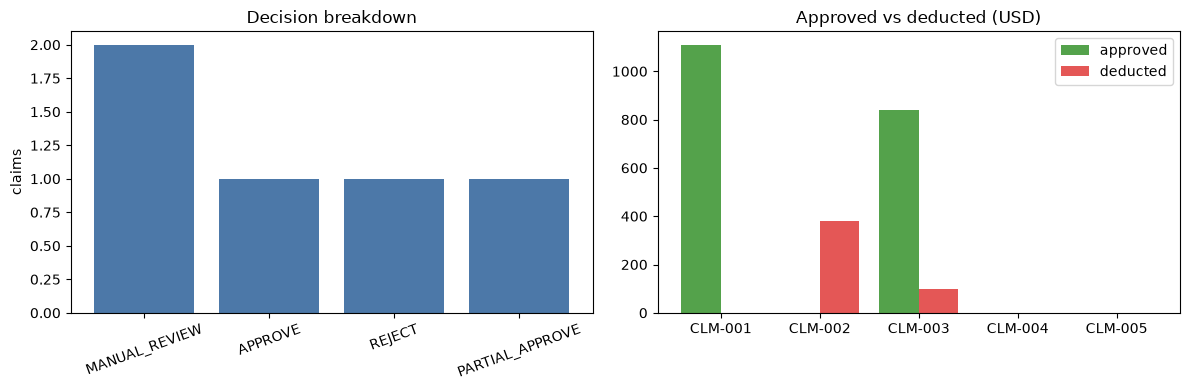

In [9]:
all_results, all_audit = [], []
for c in claims:
    r, a = run_claim(c["claim_id"])
    all_results.append(r)
    all_audit.append(a)
    print(c["claim_id"], "->", r["decision"])

df = pd.DataFrame(all_results)
audit_df = pd.DataFrame(all_audit)

# summary table
print()
display(df[["claim_id", "decision", "approved_amount", "deducted_amount", "confidence"]])
print("total approved: $%.2f | total deducted: $%.2f" % (df["approved_amount"].sum(), df["deducted_amount"].sum()))

# audit trail
display(audit_df)

# charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["decision"].value_counts()
axes[0].bar(counts.index, counts.values, color="#4C78A8")
axes[0].set_title("Decision breakdown")
axes[0].set_ylabel("claims")
axes[0].tick_params(axis="x", rotation=20)

x = range(len(df))
axes[1].bar([i - 0.2 for i in x], df["approved_amount"], width=0.4, label="approved", color="#54A24B")
axes[1].bar([i + 0.2 for i in x], df["deducted_amount"], width=0.4, label="deducted", color="#E45756")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df["claim_id"])
axes[1].set_title("Approved vs deducted (USD)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Sample outputs

Decision and explanation for every claim:

In [10]:
for r in all_results:
    print(r["claim_id"], "|", r["decision"], "| approved $%.2f, deducted $%.2f" % (r["approved_amount"], r["deducted_amount"]))
    print("   ", r["explanation"])
    print()

CLM-001 | APPROVE | approved $1110.00, deducted $0.00
    All checks passed cleanly. Here's my review of claim CLM-001:

**Eligibility** (POL-CAT-01): All items are eligible — airfare $420, lodging $360, meals $180, conference fees $150. No ineligible items (no spa/minibar/alcohol, etc.). Ineligible total: $0.

**Limits** (POL-PD-01, POL-PD-02): No deductions. Meals $180 vs. cap $225 (3 days × $75); lodging $360 vs. cap $400 (2 nights × $200).

**Receipt

CLM-002 | REJECT | approved $0.00, deducted $380.00
    ## Final Decision: REJECT

**Claim CLM-002**

**Reasoning:**
- **Eligibility:** Every item on this claim is ineligible — a $300 spa charge and an $80 minibar charge. There are no eligible items. Per **POL-CAT-02**, spa and minibar are never reimbursable and are deducted in full.
- **Limits:** No per diem/category cap issues, but this is moot since no items are eligible.
- **Receipts:** No missing 

CLM-003 | PARTIAL_APPROVE | approved $840.00, deducted $100.00
    ## Final Decisi

### Simple UI

Pick a claim, press the button and the agent runs live on it. (Needs `ipywidgets`, works in Jupyter notebook / lab.)

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output

claim_picker = widgets.Dropdown(
    options=[(c["claim_id"] + " - " + c["purpose"], c["claim_id"]) for c in claims],
    description="Claim:",
    layout=widgets.Layout(width="650px"),
)
run_button = widgets.Button(description="Review claim", button_style="primary")
ui_out = widgets.Output()


def on_click(_):
    with ui_out:
        clear_output()
        r, a = run_claim(claim_picker.value)
        print(json.dumps(r, indent=2))
        print()
        print("audit:", a)


run_button.on_click(on_click)
display(widgets.VBox([claim_picker, run_button, ui_out]))

## Design Notes & Reasoning

**What I built**
A LangChain agent that reviews travel claims. The agent picks tools, reads the results and writes the explanation. A plain python rule engine checks the agent and is the fallback.

**Why rules are plain python and not LLM**
Per diem math, receipt checks and tiers must be correct every time, and LLMs can get math wrong. So the policy logic is in normal functions. The LLM does the orchestration (which tool to call) and the explanation. Final amounts, policy refs, missing docs and confidence come from the rules only.

**Why tools take only `claim_id`**
Models can mess up when they have to copy a big json into tool arguments. With just the id it is much safer.

**Why LangChain and DeepSeek**
LangChain gave me `@tool` for the tools, `create_agent` for the agent loop and `with_structured_output` for the final verdict, so I wrote very little glue code. The tool calls in the message history also give me the audit trail and the `tools_used` field. I first tried free HuggingFace models, but the free credits were not available anymore, so I switched to the DeepSeek API (`ChatDeepSeek`). It is cheap, the whole demo costs a few cents.

**How the agent flow works**
1. Rule engine runs first, that is the safe answer.
2. The agent runs and calls the tools it wants.
3. The agent's final text is turned into a small verdict (decision + explanation) in a separate step. If that step fails I look for the decision word in the text instead.
4. If the agent crashes, calls no tools, or gives a different decision than the rules, I use the rule engine result.
5. Pydantic validates the 9 output fields at the end.

In my run the agent used the tools and agreed with the rule engine on all 5 claims.

**Why these go to Manual Review**
- CLM-004: business class (POL-AIR-01, it may have a pre-approval so I do not auto deduct), lodging receipt missing (POL-RCT-02) and total $3000 is over $2000 (POL-APR-03). Also the claim says 3 nights but the trip dates only give 2, so that is conflicting info too.
- CLM-005: $220 is over $25 and has no receipt (POL-RCT-02). Also it is a dinner for 4 but per diem is $75 per day, and it is not clear if that is per person, so I do not force a deduction.
- The policy says prefer Manual Review over forcing a decision, so unknown categories, unclear airfare class and late claims go there as well.

**Assumptions**
- Days are inclusive (10th to 12th is 3 days, 2 nights). Meals cap is days x $75 and lodging cap is nights x $200, over the whole trip. For lodging I use the nights written on the claim, and if that does not match the trip dates I flag it as conflicting info.
- Expense date = trip end date for the 30 day check.
- Approval tier is checked on the total after per diem deductions, like the policy says.
- For MANUAL_REVIEW, approved_amount is 0 because nothing is approved yet. deducted_amount only has the sure deductions (ineligible items and per diem excess).
- A group meal is detected with simple text like "for 4" in the description.
- Confidence is a simple number from the rules: 0.95 for clean approve or reject, 0.9 for partial, 0.85 for manual review with a clear rule, 0.6 for manual review because of ambiguity.
- Mock data only, no real employee data.

**Trade-offs**
- No vector db or embeddings, the policy is small so a keyword lookup is enough.
- If the LLM disagrees with the rules I trust the rules. Less freedom for the AI but more reliable.
- Needs a paid API key now (very small cost). Without a key the notebook still runs with rules only.
- Did not do extra things (MCP, chatbot, eval suite) because of the 2-3 hour time limit.

**Known gaps / what I would improve next**
- Line items have no per-item dates, so per diem is checked on the whole trip and not day by day.
- Group meals need a proper attendee count field, not a regex on the description.
- Duplicate claim detector and currency conversion.
- A small test set and an eval script to compare different models.
- Shorter explanations from the LLM, right now they can be long.
- Retry logic for API rate limits and errors.

In [11]:
# final results, one object per claim, exactly the 9 required fields
print(json.dumps(all_results, indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01"
    ],
    "confidence": 0.95,
    "explanation": "All checks passed cleanly. Here's my review of claim CLM-001:\n\n**Eligibility** (POL-CAT-01): All items are eligible \u2014 airfare $420, lodging $360, meals $180, conference fees $150. No ineligible items (no spa/minibar/alcohol, etc.). Ineligible total: $0.\n\n**Limits** (POL-PD-01, POL-PD-02): No deductions. Meals $180 vs. cap $225 (3 days \u00d7 $75); lodging $360 vs. cap $400 (2 nights \u00d7 $200).\n\n**Receipt",
    "tools_used": [
      "check_eligibility",
      "check_limits",
      "check_receipts",
      "check_approval_rules"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_doc